# 06 NMI predictive linkage

This notebook owns the new NMI-facing computations directly, following the same pattern as notebooks 00--05. It uses the existing scientific models in `mrl_trace`, reads the measured Au and ITO files, and keeps results in notebook variables in smoke/reduced mode unless saving is enabled. Publication mode saves its complete artifact contract.

Historical arrays that encode the transformed retention, one-choice task or withdrawn dopamine capstone are not compatible with this analysis. Smoke and reduced runs test execution only; corrected publication claims require fresh publication-profile results.


## Workload controls

Set `MRL_RUN_PROFILE=smoke|reduced|publication` and `MRL_WORKERS`. The default `reduced` execution is suitable for a laptop feasibility run. Smoke and reduced outputs are feasibility diagnostics; only `publication` is intended for final inference. Publication mode requires and defaults both artifact switches on; smoke/reduced runs may opt in with `MRL_SAVE_RESULTS=1` and/or `MRL_SAVE_FIGURES=1`. Set `MRL_OUTPUT_DIR` to an external DOI-staging directory. Existing outputs require `MRL_OVERWRITE=1`.

| Analysis | Smoke | Reduced | Publication |
|---|---:|---:|---:|
| Au/ITO bootstrap | 500 | 2,000 | 10,000 |
| Primary timing | 2 seeds x 80 trials | 6 x 500 | 20 x 1,500 |
| Supported-k sensitivity | 1 x 30 | 3 x 300 | 20 x 1,500 |
| Retention holdout | 2 x 80 episodes | 6 x 300 | 20 x 800 |
| Reversal quantiles | 3 x 400 trials | 6 x 1,200 | 20 x 3,000 |

Laptop smoke run (PowerShell):

```powershell
python -m pip install -e ".[repro,test]"
$env:MRL_RUN_PROFILE = "smoke"
$env:MRL_WORKERS = "4"
python -m jupyter nbconvert --to notebook --execute --ExecutePreprocessor.timeout=-1 --output 06_nmi_predictive_linkage.executed.ipynb experiments/06_nmi_predictive_linkage.ipynb
```

For a publication run, change the profile to `publication` and set `MRL_OUTPUT_DIR` to persistent storage outside the checkout; result and figure saving then default on and cannot be disabled. The same command runs on a workstation, HPC node, ordinary cloud VM or SageMaker; SageMaker is not scientifically required. Start with smoke and reduced runs to measure scaling before selecting hardware. Run the publication profile twice into distinct directories, compare the deterministic manifests/statistics, and archive the executed notebooks, NumPy/JSON outputs, commit, environment and logs with the DOI.

## Archive compatibility and provenance

The absence of full-sweep `.npy` files from Git is not evidence that the original experiments were not run. It also does not make historical arrays scientifically interchangeable with corrected results. Archives from commit `2288c53` remain provenance records only: the old one-choice `exp6_sequential.npy`, transformed-retention analyses and dopamine capstone must not be loaded as evidence for the repaired claims.

The corrected computations owned here are replicate-level held-out empirical-model comparison, direct-held-bias ITO timing sweeps with matched controls, cascade-representation sensitivity, a simulated retention–delay design curve and four-quantile reversal with a post-peak decay-matched exponential. Git retains code, reduced executable notebooks, parameter/source tables and small fixtures. Publication-scale per-seed outputs, logs, environment records and figure sources belong in the archival DOI.


In [1]:
from pathlib import Path
from IPython.display import display
import csv, hashlib, json, math, os, platform, re, subprocess, sys, time
from importlib import metadata as importlib_metadata

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd().resolve()
REPO_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "src" / "mrl_trace").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from the mrl-trace checkout or a subdirectory")
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))
try:
    SOURCE_COMMIT = subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, check=True,
        text=True, capture_output=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    SOURCE_COMMIT = os.getenv("MRL_SOURCE_COMMIT", "unavailable")
ENVIRONMENT_RECORD = {
    "python": platform.python_version(), "platform": platform.platform(),
    "packages": {name: importlib_metadata.version(name) for name in (
        "numpy", "scipy", "matplotlib", "mrl-trace"
    )},
}

RUN_PROFILE = os.getenv("MRL_RUN_PROFILE", "reduced").strip().lower()
if RUN_PROFILE == "quick":
    RUN_PROFILE = "smoke"
if RUN_PROFILE not in {"smoke", "reduced", "publication"}:
    raise ValueError("MRL_RUN_PROFILE must be smoke, reduced or publication")
DEVICE = os.getenv("MRL_DEVICE", "cpu")
WORKERS = max(1, int(os.getenv("MRL_WORKERS", "1")))
_publication_default = "1" if RUN_PROFILE == "publication" else "0"
SAVE_FIGURES = os.getenv("MRL_SAVE_FIGURES", _publication_default).lower() in {"1", "true", "yes"}
OVERWRITE = os.getenv("MRL_OVERWRITE", "0").lower() in {"1", "true", "yes"}
RUN_EXTERNAL_DATA = os.getenv("MRL_RUN_EXTERNAL_DATA", "0").lower() in {"1", "true", "yes"}
ALLOW_DATA_DOWNLOADS = os.getenv("MRL_ALLOW_DATA_DOWNLOADS", "0").lower() in {"1", "true", "yes"}
SAVE_RESULTS = os.getenv("MRL_SAVE_RESULTS", _publication_default).lower() in {"1", "true", "yes"}
if RUN_PROFILE == "publication" and not (SAVE_RESULTS and SAVE_FIGURES):
    raise RuntimeError("publication mode requires result tables and figures to be saved")
OUTPUT_DIR = Path(os.getenv("MRL_OUTPUT_DIR", REPO_ROOT / "data" / "nmi-results")).expanduser().resolve()
if RUN_PROFILE == "publication" and "MRL_OUTPUT_DIR" not in os.environ:
    raise RuntimeError("publication mode requires an explicit external MRL_OUTPUT_DIR")
BOOTSTRAP = {"smoke": 500, "reduced": 2000, "publication": 10000}[RUN_PROFILE]
OWNED = ("fig_nmi_physical_model.png", "fig_nmi_predictive_timing.png",
         "fig_nmi_retention_delay.png", "fig_nmi_reversal.png")
RESULT_ARTIFACTS = ("raw_manifest.csv", "raw_manifest.json", "gold_cv_rows.csv",
    "gold_fit_rows.csv", "ito_fit_rows.csv", "predictive_interval_seeds.csv",
    "retention_delay_seeds.csv", "reversal_seeds.csv", "figure_sources.json",
    "gold_parameters.json", "predictive_linkage_manifest.json", "run_report.json",
    "identifiability_support.json", "kernel_theory_rows.csv",
    "timing_battery.json", "falsification_predictions.json",
    f"nmi_predictive_linkage_{RUN_PROFILE}.npy",
    f"nmi_predictive_linkage_{RUN_PROFILE}.json")
_requested_outputs = ((*OWNED,) if SAVE_FIGURES else ()) + (
    RESULT_ARTIFACTS if SAVE_RESULTS else ()
)
_existing_outputs = [str(OUTPUT_DIR / name) for name in _requested_outputs
                     if (OUTPUT_DIR / name).exists()]
if _existing_outputs and not OVERWRITE:
    raise FileExistsError(f"refusing to overwrite publication artifacts: {_existing_outputs}")
FIGURE_REPORT = []
def finish(fig, filename, sources):
    if filename not in OWNED:
        raise ValueError(f"unregistered figure {filename}")
    display(fig)
    record = {"filename": filename, "sources": list(sources),
              "profile": RUN_PROFILE, "saved": False}
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        target = OUTPUT_DIR / filename
        if target.exists() and not OVERWRITE:
            raise FileExistsError(f"refusing to overwrite {target}")
        fig.savefig(target, dpi=300, bbox_inches="tight")
        record["saved"] = True
    FIGURE_REPORT.append(record)
    plt.close(fig)
PROVENANCE_RECORD = {
    "source_commit": SOURCE_COMMIT,
    "environment": ENVIRONMENT_RECORD,
    "historical_archive_commit": "2288c53bde5fd3fbc41c4db43cd9c48a7ce5ab4a",
    "original_law": {"beta_fill": 2.0, "cascade_k": 3,
                     "tau_r_s": [145.0, 2.9], "tau_d_s": [11700.0, 3.9]},
    "historical_archives_evidential_status": "provenance_only; incompatible with corrected retention/task schemas",
    "new_computation": ["physical_model_comparison", "timing_prediction",
                         "cascade_representation_sensitivity", "retention_design_curve",
                         "reversal_quantiles"],
    "distribution": {"git": "code, reduced notebooks, tables, small fixtures",
                     "doi": "full per-seed outputs, logs, environment, figure sources"},
}
print({"profile": RUN_PROFILE, "device": DEVICE, "workers": WORKERS,
       "bootstrap": BOOTSTRAP, "save_results": SAVE_RESULTS,
       "save_figures": SAVE_FIGURES, "output_dir": str(OUTPUT_DIR)})


{'profile': 'reduced', 'device': 'auto', 'workers': 4, 'bootstrap': 2000, 'save_results': False, 'save_figures': False, 'output_dir': 'C:\\Users\\User\\git\\mrl-trace\\experiments\\generated_figures'}


## 1. Replicate-level physical identification

The following cell contains the complete measured-data analysis used here: raw-file hashing, grouped leave-one-bias-out Au model comparison, explicit ITO quality control and experimental-trace bootstrap summaries. It is embedded so this experiment does not depend on a new source-package module.


In [2]:
"""Publication-grade analysis of the measured Au and ITO transients.

The learning modules deliberately remain small numerical reference models.  This
workflow implements the stronger evidential contract needed by the paper: every raw file is
hashed, Au traces are fitted as individual replicates with bias-grouped validation,
and every ITO workbook receives an explicit quality-control outcome.  No synthetic
device population is created here.
"""
from __future__ import annotations

import contextlib
import csv
import hashlib
import io
import json
import math
import re
from pathlib import Path
from typing import Iterable

import numpy as np
from scipy.optimize import least_squares
from scipy.special import gammainc
from mrl_trace.model_specs import (PRIMARY_MODEL_ID, LINEAR_MODEL_ID, build_predictive_linkage_manifest, device_model_spec, select_supported_state_space)
from mrl_trace.predictive_linkage import (candidate_response as shared_candidate_response, affine_trace_score as shared_affine_trace_score, fit_candidate as shared_fit_candidate, default_candidates, grouped_held_out_scores, bootstrap_held_out_support)
from mrl_trace.kernel_theory import kernel_phase_map
from mrl_trace.timing_benchmarks import run_matched_timing_benchmark
from mrl_trace.falsification import build_falsification_predictions
from mrl_trace.paths import select_ito_source_cohort

TRAIN_BIASES = (0.8, 0.9, 1.1, 1.2, 1.4, 1.5)
OOD_BIASES = (1.7, 1.8)
GOLD_RE = re.compile(r"trace_V([mp])(\d+(?:\.\d+)?)_tr(\d+)\.csv$")
ITO_RE = re.compile(
    r"(?P<protocol>voltage bias|current stress)#\d+ Run(?P<run>\d+) "
    r"(?P<date>\d{2}-\d{2}-\d{4})\.xls$",
    re.IGNORECASE,
)
NEAR_ZERO_MAX_V = 0.002


def _measurement_regime(bias_v: float) -> str:
    """Separate preliminary near-zero reads from held-bias kinetics."""
    value = float(abs(bias_v))
    if not np.isfinite(value):
        return "unknown_bias"
    return "near_zero_read" if value <= NEAR_ZERO_MAX_V else "held_bias"


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for block in iter(lambda: fh.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def resolve_gold_dir(value: str | Path | None = None) -> Path:
    """Resolve the Au CSV directory without creating it."""
    import os

    candidates = []
    if value is not None:
        candidates.append(Path(value))
    if os.environ.get("MRL_TRACE_GOLD_DIR"):
        candidates.append(Path(os.environ["MRL_TRACE_GOLD_DIR"]))
    root = REPO_ROOT
    candidates.extend((
        root / "data" / "raw" / "gold_export",
        root.parent / "current_transient" / "gold_export",
        root / "data" / "device_model" / "gold_export",
    ))
    for candidate in candidates:
        if candidate.is_dir() and len(list(candidate.glob("trace_*.csv"))) == 24:
            return candidate.resolve()
    raise FileNotFoundError(
        "Au raw directory with 24 trace CSVs not found; set MRL_TRACE_GOLD_DIR"
    )


def resolve_ito_dir(value: str | Path | None = None) -> Path:
    """Resolve the ITO workbook directory without creating it."""
    import os

    candidates = []
    if value is not None:
        candidates.append(Path(value))
    if os.environ.get("MRL_TRACE_ITO_DIR"):
        candidates.append(Path(os.environ["MRL_TRACE_ITO_DIR"]))
    root = REPO_ROOT
    candidates.extend((root / "data" / "raw" / "ito", Path.home() / "Downloads" / "ITO data"))
    for candidate in candidates:
        if not candidate.is_dir():
            continue
        try:
            select_ito_source_cohort(candidate)
        except FileNotFoundError:
            continue
        return candidate.resolve()
    raise FileNotFoundError(
        "ITO raw directory with the 91-workbook primary cohort and two 1 mV supplements not found; set MRL_TRACE_ITO_DIR"
    )


def _read_xls(path: Path) -> tuple[list[str], np.ndarray, dict[str, str]]:
    try:
        import xlrd
    except ImportError as exc:  # pragma: no cover - dependency error is explicit
        raise RuntimeError("ITO parsing requires the 'repro' extra (xlrd)") from exc

    # The instrument emits harmless OLE consistency notices for its non-sector-aligned
    # legacy files. Keep them out of the publication log while preserving the raw hash.
    notices = io.StringIO()
    with contextlib.redirect_stdout(notices), contextlib.redirect_stderr(notices):
        book = xlrd.open_workbook(path, on_demand=True, logfile=notices)
    sheet = book.sheet_by_name("Sheet1")
    headers = [str(sheet.cell_value(0, col)).strip() for col in range(sheet.ncols)]
    values = np.asarray([
        [sheet.cell_value(row, col) for col in range(sheet.ncols)]
        for row in range(1, sheet.nrows)
    ], dtype=float)
    metadata: dict[str, str] = {}
    if "Sheet3" in book.sheet_names():
        meta = book.sheet_by_name("Sheet3")
        for row in range(meta.nrows):
            key = str(meta.cell_value(row, 0)).strip()
            if key:
                metadata[key] = str(meta.cell_value(row, 1)).strip()
    book.release_resources()
    return headers, values, metadata


def raw_manifest(gold_dir: Path, ito_dir: Path) -> list[dict[str, object]]:
    """Return one immutable provenance row for every raw source file."""
    rows: list[dict[str, object]] = []
    for path in sorted(gold_dir.glob("trace_*.csv")):
        match = GOLD_RE.match(path.name)
        if not match:
            continue
        sign, magnitude, trial = match.groups()
        with path.open("r", encoding="utf-8", newline="") as fh:
            reader = csv.reader(fh)
            columns = next(reader)
            sample_count = sum(1 for _ in reader)
        rows.append({
            "dataset": "au_transient", "filename": path.name,
            "sha256": sha256_file(path), "bytes": path.stat().st_size,
            "electrode": "Au/Ti", "protocol": "voltage_step",
            "device_identity": "single_Au_device", "experimental_unit": "recorded_trace_run",
            "bias_v": (-1 if sign == "m" else 1) * float(magnitude),
            "trial_or_run": int(trial), "date": "not_recorded",
            "columns": "|".join(columns), "sample_count": sample_count,
            "qc_status": "pending_fit", "qc_reason": "",
        })

    ito_cohort = select_ito_source_cohort(ito_dir)
    primary_workbooks = set(ito_cohort["primary_workbooks"])
    supplemental_workbooks = set(ito_cohort["supplemental_workbooks"])
    analysis_workbooks = set(ito_cohort["workbooks"])
    all_workbooks = sorted((*ito_cohort["workbooks"], *ito_cohort["additional_workbooks"]))
    for path in all_workbooks:
        in_primary_cohort = path in primary_workbooks
        in_supplemental_cohort = path in supplemental_workbooks
        in_analysis_cohort = path in analysis_workbooks
        match = ITO_RE.search(path.name)
        headers, values, metadata = _read_xls(path)
        protocol = match.group("protocol").lower().replace(" ", "_") if match else "unknown"
        bias = metadata.get("Bias", "")
        try:
            bias_v: float | str = float(bias)
        except ValueError:
            bias_v = ""
        rows.append({
            "dataset": "ito_relaxation", "filename": path.name,
            "sha256": sha256_file(path), "bytes": path.stat().st_size,
            "electrode": "ITO", "protocol": protocol, "bias_v": bias_v,
            "measurement_regime": (
                _measurement_regime(bias_v) if isinstance(bias_v, float)
                and protocol == "voltage_bias" else "conditioning"
            ),
            "device_identity": "unrecoverable", "experimental_unit": "workbook_run",
            "trial_or_run": int(match.group("run")) if match else "",
            "date": match.group("date") if match else metadata.get("Last Executed", ""),
            "source_cohort": ("primary_january_2025" if in_primary_cohort else
                              ("supplemental_near_zero_june_2026"
                               if in_supplemental_cohort else "later_addition")),
            "columns": "|".join(headers), "sample_count": int(values.shape[0]),
            "qc_status": ("excluded" if not in_analysis_cohort else
                          ("pending_fit" if protocol == "voltage_bias" else "not_decay_protocol")),
            "qc_reason": ("later acquisition outside frozen January 2025 cohort"
                          if not in_analysis_cohort else
                          ("conditioning/current-stress file" if protocol != "voltage_bias" else "")),
        })
    return rows


def load_gold_traces(gold_dir: Path, *, n_grid: int = 240) -> list[dict[str, object]]:
    traces: list[dict[str, object]] = []
    for path in sorted(gold_dir.glob("trace_*.csv")):
        match = GOLD_RE.match(path.name)
        if not match:
            continue
        sign, magnitude, trial = match.groups()
        arr = np.genfromtxt(path, delimiter=",", names=True)
        t = np.asarray(arr["time"], float)
        current = np.abs(np.asarray(arr["current"], float))
        valid = np.isfinite(t) & np.isfinite(current) & (t >= 0) & (current > 0)
        t, current = t[valid], current[valid]
        if t.size < 20:
            raise ValueError(f"too few valid Au samples in {path.name}")
        indices = np.unique(np.linspace(0, t.size - 1, min(n_grid, t.size)).astype(int))
        traces.append({
            "filename": path.name, "bias": float(magnitude), "signed_bias":
            (-1 if sign == "m" else 1) * float(magnitude), "trial": int(trial),
            "time": t[indices] - t[indices][0], "current": current[indices],
        })
    if len(traces) != 24:
        raise ValueError(f"expected 24 Au traces, found {len(traces)}")
    return traces


def _kinetic_shape(t: np.ndarray, bias: float, theta: np.ndarray,
                   model: str, k: int | None = None) -> np.ndarray:
    representation = {"cascade": LINEAR_MODEL_ID, "physical": PRIMARY_MODEL_ID}.get(model, model)
    return shared_candidate_response(t, bias, theta, representation, k=k)


def _affine_fit(shape: np.ndarray, observed: np.ndarray) -> tuple[np.ndarray, float, float]:
    prediction, amplitude, offset, _ = shared_affine_trace_score(shape, observed)
    return prediction, amplitude, offset


def _fit_gold_model(traces: Iterable[dict[str, object]], model: str,
                    k: int | None = None) -> tuple[np.ndarray, list[dict[str, float]]]:
    traces = list(traces)
    representation = {"cascade": LINEAR_MODEL_ID, "physical": PRIMARY_MODEL_ID}.get(model, model)
    theta = shared_fit_candidate(traces, representation, k=k)
    return theta, score_gold_model(traces, theta, model, k)


def score_gold_model(traces: Iterable[dict[str, object]], theta: np.ndarray,
                     model: str, k: int | None = None) -> list[dict[str, float]]:
    rows: list[dict[str, float]] = []
    for trace in traces:
        y = np.asarray(trace["current"], float)
        shape = _kinetic_shape(np.asarray(trace["time"], float), float(trace["bias"]),
                               theta, model, k)
        prediction, amplitude, offset = _affine_fit(shape, y)
        scale = max(float(np.ptp(y)), float(np.max(np.abs(y))), 1e-15)
        nrmse = float(np.sqrt(np.mean(np.square(prediction - y))) / scale)
        rows.append({
            "bias": float(trace["bias"]), "trial": int(trace["trial"]),
            "nrmse": nrmse, "amplitude_a": amplitude, "offset_a": offset,
        })
    return rows


def _bootstrap_mean_ci(values: np.ndarray, *, samples: int = 10000,
                       seed: int = 20260717) -> tuple[float, float]:
    values = np.asarray(values, float)
    rng = np.random.default_rng(seed)
    means = np.empty(samples)
    for start in range(0, samples, 1000):
        stop = min(samples, start + 1000)
        draw = rng.integers(0, values.size, size=(stop - start, values.size))
        means[start:stop] = values[draw].mean(axis=1)
    return tuple(float(x) for x in np.percentile(means, (2.5, 97.5)))


def _bootstrap_grouped_mean_ci(values: np.ndarray, groups: np.ndarray, *,
                               samples: int = 10000,
                               seed: int = 20260717) -> tuple[float, float]:
    """Bootstrap a paired mean while resampling whole validation-bias groups.

    The 24 Au files are repeated runs from one device, not 24 independent devices.
    Trace-level resampling is retained as a descriptive sensitivity analysis, but the
    grouped interval is the conservative uncertainty statement for model comparison.
    """
    values = np.asarray(values, float)
    groups = np.asarray(groups)
    unique = np.unique(groups)
    group_means = np.asarray([values[groups == group].mean() for group in unique])
    return _bootstrap_mean_ci(group_means, samples=samples, seed=seed)


def identify_gold_models(gold_dir: Path, *, bootstrap_samples: int = 10000,
                         n_grid: int = 240) -> dict[str, object]:
    """Grouped leave-one-bias-out comparison of KWW and cascade models.

    The primary cascade representative minimises pooled held-out NRMSE. Fold votes
    are reported only as a stability diagnostic: using ``Counter.most_common`` made a
    tied vote depend on candidate ordering and previously froze an arbitrary ``k=1``.
    Stability of an integer approximation depth and support for a compressed rise
    are reported separately; neither identifies a microscopic trap count.
    """
    traces = load_gold_traces(gold_dir, n_grid=n_grid)
    training = [t for t in traces if float(t["bias"]) in TRAIN_BIASES]
    ood = [t for t in traces if float(t["bias"]) in OOD_BIASES]
    cv_rows: list[dict[str, object]] = []
    best_k_by_fold: list[int] = []
    kww_beta_by_fold: list[float] = []

    for heldout in TRAIN_BIASES:
        train_fold = [t for t in training if float(t["bias"]) != heldout]
        test_fold = [t for t in training if float(t["bias"]) == heldout]
        candidates: dict[str, list[dict[str, float]]] = {}
        theta, candidates["kww"] = _fit_gold_model(train_fold, "kww")
        kww_beta_by_fold.append(float(math.exp(theta[4])))
        candidates["kww"] = score_gold_model(test_fold, theta, "kww")
        for stages in range(1, 6):
            theta, _ = _fit_gold_model(train_fold, "cascade", stages)
            candidates[f"cascade_k{stages}"] = score_gold_model(
                test_fold, theta, "cascade", stages)
        best_k = min(range(1, 6), key=lambda stage: np.mean([
            row["nrmse"] for row in candidates[f"cascade_k{stage}"]
        ]))
        best_k_by_fold.append(best_k)
        for name, scored in candidates.items():
            for row in scored:
                cv_rows.append({"heldout_bias": heldout, "model": name, **row})

    full_parameters: dict[str, dict[str, float]] = {}
    full_scores: list[dict[str, object]] = []
    for name, model, stages in [
        ("kww", "kww", None),
        *[(f"cascade_k{k}", "cascade", k) for k in range(1, 6)],
    ]:
        theta, rows = _fit_gold_model(training, model, stages)
        params = {
            "tr0_s": math.exp(theta[0]), "cr_per_v": float(theta[1]),
            "td0_s": math.exp(theta[2]), "cd_per_v": float(theta[3]),
        }
        if model == "kww":
            params["beta_fill"] = math.exp(theta[4])
        full_parameters[name] = params
        for row in score_gold_model(ood, theta, model, stages):
            full_scores.append({"split": "ood", "model": name, **row})
        for row in rows:
            full_scores.append({"split": "training", "model": name, **row})

    def cv_values(name: str) -> np.ndarray:
        ordered = sorted((r for r in cv_rows if r["model"] == name),
                         key=lambda r: (r["bias"], r["trial"]))
        return np.asarray([r["nrmse"] for r in ordered], float)

    model_names = [f"cascade_k{stage}" for stage in range(1, 6)] + ["kww"]
    cv_mean_by_model = {
        name: float(cv_values(name).mean()) for name in model_names
    }
    selected_k = min(range(1, 6),
                     key=lambda stage: cv_mean_by_model[f"cascade_k{stage}"])
    winner_counts = {
        str(stage): int(best_k_by_fold.count(stage)) for stage in range(1, 6)
    }
    max_wins = max(winner_counts.values())
    modal_k = [int(stage) for stage, count in winner_counts.items()
               if count == max_wins]

    cascade = cv_values(f"cascade_k{selected_k}")
    mono = cv_values("cascade_k1")
    kww = cv_values("kww")
    improvement = mono - cascade
    heldout_groups = np.asarray([
        row["heldout_bias"] for row in sorted(
            (r for r in cv_rows if r["model"] == f"cascade_k{selected_k}"),
            key=lambda r: (r["bias"], r["trial"])
        )
    ])
    trace_improvement_ci = _bootstrap_mean_ci(
        improvement, samples=bootstrap_samples)
    grouped_improvement_ci = _bootstrap_grouped_mean_ci(
        improvement, heldout_groups, samples=bootstrap_samples)
    best_mean = cv_mean_by_model[f"cascade_k{selected_k}"]
    supported_k = [stage for stage in range(1, 6)
                   if cv_mean_by_model[f"cascade_k{stage}"] <= 1.05 * best_mean]
    fold_compression_consistent = bool(min(kww_beta_by_fold) > 1.0)
    representative_depth_stable = bool(len(modal_k) == 1 and modal_k[0] == selected_k and
                                max_wins >= 4 and len(supported_k) == 1)
    evidence = {
        "selected_k": selected_k,
        "selection_rule": "minimum pooled grouped-LOBO trace-level mean NRMSE",
        "best_k_by_fold": best_k_by_fold,
        "fold_winner_counts": winner_counts,
        "modal_k": modal_k,
        "supported_k_within_5pct_of_best": supported_k,
        "representative_depth_status": "stable" if representative_depth_stable else "unstable",
        "compressed_rise_status": (
            "consistent_across_bias_folds" if fold_compression_consistent
            else "not_consistent_across_bias_folds"
        ),
        "kww_beta_fill_by_fold": kww_beta_by_fold,
        "kww_beta_fill_full": full_parameters["kww"]["beta_fill"],
        "historical_beta_fill_reference": {
            "mean": 1.95, "sd": 0.30,
            "source": "historical manuscript averaged-trace analysis",
            "reconciliation_status": (
                "Both analyses support beta_fill > 1, but their numerical difference "
                "still requires a fit-window, preprocessing and objective audit."
            ),
        },
        "cv_mean_nrmse_by_model": cv_mean_by_model,
        "cascade_mean_nrmse": float(cascade.mean()),
        "single_stage_mean_nrmse": float(mono.mean()),
        "kww_mean_nrmse": float(kww.mean()),
        "selected_minus_single_stage_improvement_mean": float(improvement.mean()),
        "selected_minus_single_stage_trace_bootstrap_95ci": list(trace_improvement_ci),
        "selected_minus_single_stage_bias_bootstrap_95ci": list(grouped_improvement_ci),
        "selected_improves_single_stage_descriptively": bool(improvement.mean() > 0),
        "selected_improvement_resolved_by_bias_bootstrap": bool(
            grouped_improvement_ci[0] > 0),
        "selected_within_5pct_of_kww": bool(cascade.mean() <= 1.05 * kww.mean()),
        "interpretation": (
            "The pooled predictive representative is frozen for simulation; the "
            "compressed rise is consistent across bias folds, while integer depth "
            "is only a model-representation sensitivity, not a microscopic stage count."
        ),
    }
    return {
        "cv_rows": cv_rows, "fit_rows": full_scores, "parameters": full_parameters,
        "evidence": evidence, "train_biases": list(TRAIN_BIASES),
        "ood_biases": list(OOD_BIASES), "trace_count": len(traces),
        "measurement_unit": "one Au device; three recorded runs per bias",
        "validation_unit": "held-out bias; errors retained per recorded run",
        "method_provenance": {
            "status": "empirical_fit",
            "established_basis": ["KWW empirical fitting", "Erlang waiting times for sequential events"],
            "repository_adaptation": "integer-cascade predictors compared with KWW by grouped held-out bias",
            "claim_limit": "predictive shape comparison; no exact KWW equivalence or microscopic stage identification",
        },
    }


def _fit_ito_trace(time: np.ndarray, current: np.ndarray) -> dict[str, float]:
    valid = np.isfinite(time) & np.isfinite(current) & (current != 0)
    time, current = time[valid], np.abs(current[valid])
    peak_index = int(np.argmax(current))
    time, current = time[peak_index:] - time[peak_index], current[peak_index:]
    n_decay = int(time.size)
    if n_decay < 10:
        raise ValueError("fewer than 10 post-peak samples")
    if time.size > 300:
        indices = np.unique(np.linspace(0, time.size - 1, 300).astype(int))
        time, current = time[indices], current[indices]
    scale = float(np.max(current))
    y = current / max(scale, 1e-30)
    floor = float(np.median(y[-max(5, y.size // 10):]))
    amplitude = max(float(y[0] - floor), 0.05)

    def stretched(z: np.ndarray, beta_fixed: float | None = None) -> np.ndarray:
        amp, tau, floor_ = math.exp(z[0]), math.exp(z[1]), math.exp(z[-1])
        beta = beta_fixed if beta_fixed is not None else math.exp(z[2])
        return amp * np.exp(-np.power(time / tau, beta)) + floor_

    z0 = np.log([amplitude, max(float(np.median(time[time > 0])), 0.1), 0.6, max(floor, 1e-8)])
    lower = np.log([1e-5, 0.01, 0.1, 1e-8])
    upper = np.log([2.0, 1e4, 2.0, 2.0])
    result = least_squares(lambda z: stretched(z) - y, z0, bounds=(lower, upper),
                           loss="soft_l1", f_scale=0.03, max_nfev=3000)
    amp, tau, beta, floor_ = np.exp(result.x)
    fit = stretched(result.x)

    exp0 = np.log([amplitude, max(float(np.median(time[time > 0])), 0.1), max(floor, 1e-8)])
    exp_result = least_squares(
        lambda z: stretched(z, 1.0) - y, exp0,
        bounds=(np.log([1e-5, 0.01, 1e-8]), np.log([2.0, 1e4, 2.0])),
        loss="soft_l1", f_scale=0.03, max_nfev=3000,
    )
    exp_fit = stretched(exp_result.x, 1.0)
    total = float(np.sum(np.square(y - y.mean())))
    r2 = 1.0 - float(np.sum(np.square(y - fit))) / total if total > 0 else float("nan")
    r2_exp = 1.0 - float(np.sum(np.square(y - exp_fit))) / total if total > 0 else float("nan")
    rho = float(floor_ / max(amp + floor_, 1e-30))
    return {
        "peak_index": peak_index, "peak_fraction": peak_index / max(valid.sum(), 1),
        "n_decay": n_decay, "end_peak_ratio": float(current[-1] / max(current[0], 1e-30)),
        "amplitude_a": float(amp * scale), "floor_a": float(floor_ * scale),
        "tau_held_s": float(tau), "beta": float(beta), "rho": rho,
        "r2_stretched": r2, "r2_exponential": r2_exp,
        "nrmse": float(np.sqrt(np.mean(np.square(y - fit)))),
    }


# Executable regression: the fitted floor is an additive offset and must not
# rescale the recovered direct kinetic time constant.
_floor_test_t = np.linspace(0.0, 15.0, 301)
_floor_test_tau = 2.3
_floor_test_fits = [
    _fit_ito_trace(_floor_test_t, np.exp(-(_floor_test_t / _floor_test_tau) ** 0.7) + floor)
    for floor in (0.05, 0.40)
]
_floor_test_recovered = [fit["tau_held_s"] for fit in _floor_test_fits]
assert np.allclose(_floor_test_recovered, _floor_test_tau, rtol=0.01), _floor_test_recovered
assert np.isclose(_floor_test_recovered[0], _floor_test_recovered[1], rtol=0.01)


def _fit_ito_workbook(path: Path) -> dict[str, object] | None:
    """Spawn-safe fit and QC audit for one ITO workbook."""
    match = ITO_RE.search(path.name)
    protocol = match.group("protocol").lower().replace(" ", "_") if match else "unknown"
    if protocol != "voltage_bias":
        return None
    headers, values, metadata = _read_xls(path)
    try:
        time = values[:, headers.index("Time")]
        current = values[:, headers.index("BI")]
        voltage = values[:, headers.index("BV")]
        fit = _fit_ito_trace(time, current)
        reasons = []
        if fit["n_decay"] < 50:
            reasons.append("fewer_than_50_post_peak_samples")
        if fit["peak_fraction"] > 0.20:
            reasons.append("peak_after_first_20pct")
        if fit["end_peak_ratio"] > 0.80:
            reasons.append("less_than_20pct_observed_decay")
        if not (0.05 <= fit["tau_held_s"] <= 100.0):
            reasons.append("tau_outside_identifiable_range")
        if not (0.1 < fit["beta"] < 2.0):
            reasons.append("beta_on_fit_bound")
        if fit["r2_stretched"] < 0.80:
            reasons.append("r2_below_0.80")
        status = "included" if not reasons else "excluded"
    except Exception as exc:  # every failure remains in the audit table
        voltage = np.asarray([float(metadata.get("Bias", "nan"))])
        fit = {}
        status, reasons = "excluded", [f"fit_error:{type(exc).__name__}"]
    bias_v = float(abs(np.nanmedian(voltage)))
    return {
        "filename": path.name, "run": int(match.group("run")) if match else "",
        "date": match.group("date") if match else metadata.get("Last Executed", ""),
        "bias_v": bias_v, "measurement_regime": _measurement_regime(bias_v),
        "qc_status": status,
        "qc_reason": "|".join(reasons), **fit,
    }


def analyse_ito(ito_dir: Path, *, bootstrap_samples: int = 10000,
                workers: int = 1) -> dict[str, object]:
    """Fit all voltage-bias workbooks and retain explicit QC outcomes.

    QC thresholds are observation-based and fixed here: at least 50 samples after
    the peak, peak in the first 20% of the record, at least a 20% observed decay,
    converged interior kinetic parameters, and R2 >= 0.80.  The beta bound is an
    interior-convergence diagnostic, not a post-hoc selection for a desired beta.
    """
    ito_cohort = select_ito_source_cohort(ito_dir)
    workbooks = list(ito_cohort["workbooks"])
    if int(workers) > 1:
        from multiprocessing import get_context
        with get_context("spawn").Pool(min(int(workers), len(workbooks))) as pool:
            fitted = pool.map(_fit_ito_workbook, workbooks, chunksize=1)
    else:
        fitted = map(_fit_ito_workbook, workbooks)
    rows = [row for row in fitted if row is not None]

    qc_passed = [row for row in rows if row["qc_status"] == "included"]
    included = [row for row in qc_passed
                if row["measurement_regime"] == "held_bias"]
    near_zero_included = [row for row in qc_passed
                          if row["measurement_regime"] == "near_zero_read"]
    if len(rows) != 72:
        raise ValueError(f"expected 72 voltage-bias ITO files, found {len(rows)}")
    if len(included) < 10:
        raise RuntimeError("too few valid ITO relaxations for population analysis")

    def included_at_r2(row: dict[str, object], threshold: float) -> bool:
        required = ("n_decay", "peak_fraction", "end_peak_ratio", "tau_held_s",
                    "beta", "r2_stretched")
        if any(key not in row for key in required):
            return False
        return bool(
            int(row["n_decay"]) >= 50 and
            float(row["peak_fraction"]) <= 0.20 and
            float(row["end_peak_ratio"]) <= 0.80 and
            0.05 <= float(row["tau_held_s"]) <= 100.0 and
            0.1 < float(row["beta"]) < 2.0 and
            float(row["r2_stretched"]) >= threshold
        )

    qc_sensitivity = []
    sensitivity_sets: dict[float, list[dict[str, object]]] = {}
    for r2_threshold in (0.70, 0.75, 0.80, 0.85, 0.90):
        sensitivity = [row for row in rows
                       if row["measurement_regime"] == "held_bias"
                       and included_at_r2(row, r2_threshold)]
        sensitivity_sets[r2_threshold] = sensitivity
        sensitivity_voltage = np.asarray([row["bias_v"] for row in sensitivity], float)
        sensitivity_tau = np.asarray([row["tau_held_s"] for row in sensitivity], float)
        sensitivity_design = np.column_stack((
            np.ones_like(sensitivity_voltage), np.sqrt(sensitivity_voltage)))
        sensitivity_coef, *_ = np.linalg.lstsq(
            sensitivity_design, np.log(1.0 / sensitivity_tau), rcond=None)
        qc_sensitivity.append({
            "r2_threshold": r2_threshold,
            "included_fits": len(sensitivity),
            "held_tau_median_s": float(np.median([
                row["tau_held_s"] for row in sensitivity
            ])),
            "beta_mean": float(np.mean([row["beta"] for row in sensitivity])),
            "beta_sd": float(np.std([row["beta"] for row in sensitivity], ddof=1)),
            "field_tau_zero_s": float(np.exp(-sensitivity_coef[0])),
            "field_slope_sqrt_v": float(sensitivity_coef[1]),
        })
    relaxed_070 = sensitivity_sets[0.70]
    historical_target_count = 53
    historical_count_reproduced = len(relaxed_070) == historical_target_count
    primary_names = {str(row["filename"]) for row in included}
    added_at_070 = [str(row["filename"]) for row in relaxed_070
                    if str(row["filename"]) not in primary_names]
    voltage = np.asarray([row["bias_v"] for row in included], float)
    tau = np.asarray([row["tau_held_s"] for row in included], float)
    beta = np.asarray([row["beta"] for row in included], float)
    design = np.column_stack((np.ones_like(voltage), np.sqrt(voltage)))
    coef, *_ = np.linalg.lstsq(design, np.log(1.0 / tau), rcond=None)
    tau_zero = float(np.exp(-coef[0]))

    rng = np.random.default_rng(20260717)
    boot_tau0 = np.empty(bootstrap_samples)
    boot_slope = np.empty(bootstrap_samples)
    for start in range(0, bootstrap_samples, 1000):
        stop = min(bootstrap_samples, start + 1000)
        for j in range(start, stop):
            indices = rng.integers(0, len(included), size=len(included))
            xb = design[indices]
            cb, *_ = np.linalg.lstsq(xb, np.log(1.0 / tau[indices]), rcond=None)
            boot_tau0[j], boot_slope[j] = np.exp(-cb[0]), cb[1]
    quantiles = np.quantile(tau, (0.10, 0.25, 0.50, 0.75))
    near_zero_tau = np.asarray([row["tau_held_s"]
                                for row in near_zero_included], float)
    near_zero_beta = np.asarray([row["beta"]
                                 for row in near_zero_included], float)
    summary = {
        "workbooks_total": 93, "primary_workbooks": 91,
        "supplemental_near_zero_workbooks": 2, "voltage_bias_files": 72,
        "additional_workbooks_disclosed": len(ito_cohort["additional_workbooks"]),
        "conditioning_files": 21, "included_fits": len(included),
        "held_bias_files": sum(row["measurement_regime"] == "held_bias" for row in rows),
        "near_zero_read_files": sum(row["measurement_regime"] == "near_zero_read" for row in rows),
        "excluded_fits": sum(row["qc_status"] == "excluded" for row in rows),
        "experimental_unit": "workbook/run",
        "device_identity_available": False,
        "held_tau_median_s": float(np.median(tau)),
        "held_tau_range_s": [float(tau.min()), float(tau.max())],
        "beta_mean": float(beta.mean()), "beta_sd": float(beta.std(ddof=1)),
        "median_r2_stretched": float(np.median([r["r2_stretched"] for r in included])),
        "median_r2_exponential": float(np.median([r["r2_exponential"] for r in included])),
        "field_law": {
            "tau_zero_s": tau_zero, "slope_sqrt_v": float(coef[1]),
            "tau_zero_bootstrap_95ci_s": [float(x) for x in np.percentile(boot_tau0, (2.5, 97.5))],
            "slope_bootstrap_95ci": [float(x) for x in np.percentile(boot_slope, (2.5, 97.5))],
            "interpretation": "held-bias extrapolation; not a direct zero-field measurement",
        },
        "near_zero_read": {
            "expected_records": 2,
            "included_records": len(near_zero_included),
            "expected_count_matches": len(near_zero_included) == 2,
            "maximum_absolute_bias_v": NEAR_ZERO_MAX_V,
            "tau_s": near_zero_tau.tolist(),
            "beta": near_zero_beta.tolist(),
            "records": [{key: row[key] for key in (
                "filename", "bias_v", "tau_held_s", "beta",
                "r2_stretched", "qc_status") if key in row}
                for row in near_zero_included],
            "interpretation": (
                "Preliminary near-zero-read measurements kept separate from "
                "held-bias quantiles and field-law fitting; they are not exact "
                "zero-field retention or evidence of electrode tuning."
            ),
        },
        "direct_held_tau_quantiles_s": {
            key: float(value) for key, value in zip(("q10", "q25", "q50", "q75"), quantiles)
        },
        "retention_definition": "direct_held_bias_tau",
        "measurement_regime": "held_bias",
        "analysis_schema_version": 2,
        "floor_interpretation": "fitted offset only; no kinetic rescaling",
        "floor_independence_regression": {"expected_tau_s": _floor_test_tau,
            "recovered_tau_s": _floor_test_recovered, "passed": True},
        "method_provenance": {
            "status": "empirical_fit",
            "established_basis": ["KWW relaxation fitting"],
            "repository_adaptation": "per-workbook held-bias fits with auditable QC",
            "claim_limit": "workbook/run is the experimental unit; device identity is unavailable",
        },
        "qc_sensitivity": {
            "primary_r2_threshold": 0.80,
            "rows": qc_sensitivity,
            "historical_target_count": historical_target_count,
            "count_at_r2_0.70": len(relaxed_070),
            "historical_count_reproduced_at_r2_0.70": historical_count_reproduced,
            "additional_files_at_r2_0.70": added_at_070,
            "interpretation": (
                "The count at R2=0.70 is reported rather than assumed to equal the "
                "historical n=53. Any remaining count or beta discrepancy requires "
                "reconciliation of fitting, preprocessing and dataset version."
            ),
        },
    }
    return {"rows": rows, "qc_sensitivity_rows": qc_sensitivity,
            "summary": summary}


def write_csv(path: Path, rows: list[dict[str, object]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fields: list[str] = []
    for row in rows:
        for key in row:
            if key not in fields:
                fields.append(key)
    with path.open("w", encoding="utf-8", newline="") as fh:
        writer = csv.DictWriter(fh, fieldnames=fields, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)


def write_json(path: Path, payload: object) -> None:
    def standards_safe(value):
        if isinstance(value, dict):
            return {str(key): standards_safe(item) for key, item in value.items()}
        if isinstance(value, (list, tuple)):
            return [standards_safe(item) for item in value]
        if isinstance(value, np.ndarray):
            return standards_safe(value.tolist())
        if isinstance(value, (np.floating, float)):
            number = float(value)
            return number if math.isfinite(number) else None
        if isinstance(value, (np.integer,)):
            return int(value)
        return value

    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(standards_safe(payload), indent=2, sort_keys=True, allow_nan=False) + "\n",
        encoding="utf-8",
    )



{'raw files': 117,
 'Au traces': 24,
 'selected k': 3,
 'supported k': [3, 4],
 'all held-out candidates': {'kww': 0.0564075041736366,
  'physical_k2': 0.13151578851519663,
  'physical_k3': 0.13176171622603483,
  'physical_k4': 0.13162797377280716,
  'physical_k5': 0.1317131596279291,
  'linear_k2': 0.05493896687393365,
  'linear_k3': 0.05480028787140087,
  'linear_k4': 0.05536816131083105,
  'linear_k5': 0.05587602351646511},
 'within 5 percent of best': ['kww',
  'linear_k2',
  'linear_k3',
  'linear_k4',
  'linear_k5'],
 'physical empirically preferred': False,
 'cascade representation depth': 'unstable',
 'candidate law': {'tr0_s': 321.1569629934206,
  'cr_per_v': 3.4327641751734728,
  'td0_s': 915.9623670773494,
  'cd_per_v': 2.039027757173861},
 'ITO summary': {'workbooks_total': 93,
  'primary_workbooks': 91,
  'supplemental_near_zero_workbooks': 2,
  'voltage_bias_files': 72,
  'additional_workbooks_disclosed': 0,
  'conditioning_files': 21,
  'included_fits': 50,
  'held_bias_

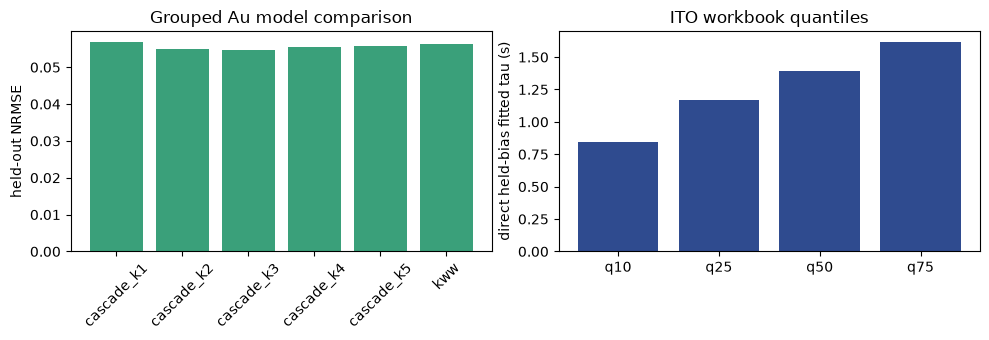

In [3]:
started = time.perf_counter()
gold_dir = resolve_gold_dir()
ito_dir = resolve_ito_dir()
raw_rows = raw_manifest(gold_dir, ito_dir)
gold_result = identify_gold_models(gold_dir, bootstrap_samples=BOOTSTRAP, n_grid=300)
gold_training_traces = [trace for trace in load_gold_traces(gold_dir, n_grid=300) if float(trace["bias"]) in TRAIN_BIASES]
state_space_comparison = grouped_held_out_scores(gold_training_traces, default_candidates())
state_space_selection = select_supported_state_space(state_space_comparison["mean_nrmse"], tolerance=0.05)
identifiability_support = bootstrap_held_out_support(
    state_space_comparison, samples=(2000 if RUN_PROFILE == "publication" else 200),
    seed=20260801, tolerance=0.05,
)
kernel_theory_rows = kernel_phase_map(
    voltages=(0.5, 0.9, 1.5), tau_leaks_s=(2.0, 10.0, 20.0),
    depths=(2, 3, 4), durations_s=(0.3,), v_max_values=(1.0,), dt_s=0.02,
)
timing_battery = run_matched_timing_benchmark(
    trials_per_block={"smoke": 4, "reduced": 16, "publication": 64}[RUN_PROFILE],
    bootstrap_samples={"smoke": 100, "reduced": 1000, "publication": 10000}[RUN_PROFILE],
)
falsification_predictions = build_falsification_predictions(
    samples={"smoke": 10, "reduced": 40, "publication": 100}[RUN_PROFILE],
    dt_s=0.05 if RUN_PROFILE == "smoke" else 0.02,
)
# Workbook fits are intentionally serial here: notebook-local functions are not
# reliably pickleable under Windows/Jupyter spawn. The learning sweeps still use WORKERS.
ito_result = analyse_ito(ito_dir, bootstrap_samples=BOOTSTRAP, workers=1)
ito_qc = {row["filename"]: row for row in ito_result["rows"]}
for manifest_row in raw_rows:
    if manifest_row["dataset"] == "au_transient":
        manifest_row["qc_status"] = "included"
        manifest_row["qc_reason"] = "passed finite-sample trace validation"
    elif manifest_row["filename"] in ito_qc:
        fitted_row = ito_qc[manifest_row["filename"]]
        manifest_row["qc_status"] = fitted_row["qc_status"]
        manifest_row["qc_reason"] = fitted_row["qc_reason"]
        manifest_row["measurement_regime"] = fitted_row["measurement_regime"]
assert not any(row["qc_status"] == "pending_fit" for row in raw_rows)
if (RUN_PROFILE == "publication" and
        not ito_result["summary"]["near_zero_read"]["expected_count_matches"]):
    raise RuntimeError("publication mode requires the two reported near-zero-read records")
physical_seconds = time.perf_counter() - started

evidence = gold_result["evidence"]
selected_k = 3  # frozen primary representation; empirical depth is not uniquely identified
supported_k = [3, 4]  # predeclared k=4 representation sensitivity
selected_law = gold_result["parameters"][f"cascade_k{selected_k}"]
quantile_map = ito_result["summary"]["direct_held_tau_quantiles_s"]
retention_quantiles = [float(quantile_map[key]) for key in ("q10", "q25", "q50", "q75")]
held_bias_beta = float(ito_result["summary"]["beta_mean"])
if ito_result["summary"]["retention_definition"] != "direct_held_bias_tau":
    raise RuntimeError("predictive linkage requires direct held-bias retention fits")
if not np.isfinite(held_bias_beta) or held_bias_beta <= 0:
    raise RuntimeError("held-bias fitted beta must be finite and positive")
eligibility_kinetics_metadata = {
    "beta_leak": held_bias_beta,
    "beta_source": "mean of direct held-bias ITO workbook KWW fits",
    "beta_status": "empirical_fit",
    "retention_values": "direct held-bias fitted tau quantiles",
    "retention_status": "measured_held_bias_quantiles",
    "claim_limit": "held-bias fitted kinetics; not field-free retention",
}
tau_r_09 = selected_law["tr0_s"] * math.exp(-selected_law["cr_per_v"] * 0.9)
tau_r_15 = selected_law["tr0_s"] * math.exp(-selected_law["cr_per_v"] * 1.5)

display({
    "raw files": len(raw_rows), "Au traces": gold_result["trace_count"],
    "selected k": selected_k, "supported k": supported_k,
    "all held-out candidates": state_space_comparison["mean_nrmse"],
    "within 5 percent of best": state_space_selection["supported_candidates"],
    "physical empirically preferred": state_space_selection["physical_within_tolerance"],
    "cascade representation depth": evidence["representative_depth_status"],
    "candidate law": selected_law, "ITO summary": ito_result["summary"],
    "eligibility kinetics": eligibility_kinetics_metadata,
    "elapsed_s": physical_seconds,
})

model_names = list(evidence["cv_mean_nrmse_by_model"])
model_values = [evidence["cv_mean_nrmse_by_model"][name] for name in model_names]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(model_names, model_values, color="#3aa07a")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set(ylabel="held-out NRMSE", title="Grouped Au model comparison")
axes[1].bar(["q10", "q25", "q50", "q75"], retention_quantiles, color="#2f4b8f")
axes[1].set(ylabel="direct held-bias fitted tau (s)", title="ITO workbook quantiles")
fig.tight_layout()
finish(fig, "fig_nmi_physical_model.png",
       ("raw_manifest", "gold_result.cv_rows", "ito_result.rows"))


## 2. Frozen prediction and learned preferred delay

The frozen candidate empirical representation predicts a preferred delay before learning is evaluated. Device, post-peak decay-matched exponential and no-trace conditions share seeded task cells and one predefined absolute delay grid for every retention; the observation grid is never recentered on a prediction. Matching fits the exponential to the frozen cascade's normalized 80--10% post-peak decay after a standard 0.3-s coincidence; it does not assign both models the same nominal retention. The device surrogate uses the mean directly fitted held-bias KWW discharge exponent; this is an empirical-fit input, not a field-free measurement. Boundary-censored peaks, exponential/no-trace peak correlations and a shuffled-prediction null are retained. Every cascade depth within 5% of the best held-out predictor is repeated as a representation-sensitivity analysis; none is interpreted as a microscopic stage count.


{'common_absolute_delay_grid_s': [0.5,
  0.75,
  1.0,
  1.4,
  2.0,
  2.8,
  4.0,
  5.7,
  8.0,
  11.3,
  16.0,
  22.6,
  32.0],
 'grid_source': 'predefined_absolute_common_grid',
 'eligibility_kinetics': {'beta_leak': 0.4698006453334779,
  'beta_source': 'mean of direct held-bias ITO workbook KWW fits',
  'beta_status': 'empirical_fit',
  'retention_values': 'direct held-bias fitted tau quantiles',
  'retention_status': 'measured_held_bias_quantiles',
  'claim_limit': 'held-bias fitted kinetics; not field-free retention'},
 'peak_censoring': {'device': {0.8448946663770562: 'right',
   1.1669372374932345: 'right',
   1.3896742156393977: 'right',
   1.6179662155669912: 'right'},
  'exp': {0.8448946663770562: 'left',
   1.1669372374932345: 'left',
   1.3896742156393977: 'left',
   1.6179662155669912: 'left'},
  'no_trace': {0.8448946663770562: 'both',
   1.1669372374932345: 'both',
   1.3896742156393977: 'both',
   1.6179662155669912: 'both'}},
 'null_controls': {'control_peak_correlatio

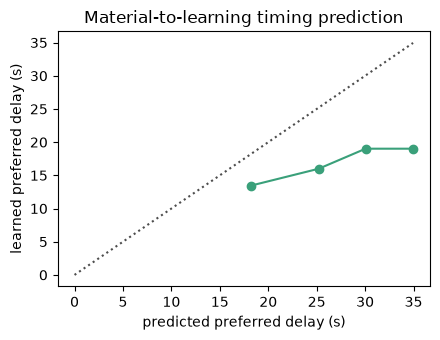

In [4]:
from mrl_trace.selectivity import PREDICTIVE_DELAY_GRID, run_predictive_interval_sweep

# Freeze one absolute observation grid before inspecting any retention-specific
# prediction. The identical grid is used for the primary and depth-sensitivity runs.
delay_grid = tuple(float(value) for value in PREDICTIVE_DELAY_GRID)

if RUN_PROFILE == "publication":
    interval_seeds, interval_trials = 20, 1500
    sensitivity_seeds, sensitivity_trials = 20, 1500
elif RUN_PROFILE == "reduced":
    interval_seeds, interval_trials = 6, 500
    sensitivity_seeds, sensitivity_trials = 3, 300
else:
    interval_seeds, interval_trials = 2, 80
    sensitivity_seeds, sensitivity_trials = 1, 30

started = time.perf_counter()
interval_result = run_predictive_interval_sweep(
    taus=retention_quantiles, seeds=interval_seeds, trials=interval_trials,
    delay_grid=delay_grid, k=selected_k, V=0.9,
    tau_r_override=tau_r_09, beta_leak=held_bias_beta, workers=WORKERS,
    retention_definition="measured_held_bias_quantiles",
)
structure_results = {}
for stages in supported_k:
    law = gold_result["parameters"][f"cascade_k{stages}"]
    structure_tau_r = law["tr0_s"] * math.exp(-law["cr_per_v"] * 0.9)
    if RUN_PROFILE == "publication" and stages == selected_k:
        structure_results[stages] = interval_result
    else:
        structure_results[stages] = run_predictive_interval_sweep(
            taus=retention_quantiles, seeds=sensitivity_seeds,
            trials=sensitivity_trials, delay_grid=delay_grid,
            k=stages, V=0.9, tau_r_override=structure_tau_r,
            beta_leak=held_bias_beta, workers=WORKERS,
            retention_definition="measured_held_bias_quantiles",
        )
interval_seconds = time.perf_counter() - started

display({"common_absolute_delay_grid_s": interval_result["delay_grid"],
         "grid_source": interval_result["grid_source"],
         "eligibility_kinetics": eligibility_kinetics_metadata,
         "peak_censoring": interval_result["peak_censoring"],
         "null_controls": {
             "control_peak_correlations": interval_result["diagnostics"]["control_peak_correlations"],
             "shuffled_prediction_one_sided_p": interval_result["diagnostics"]["shuffled_prediction_one_sided_p"],
         },
         "primary": interval_result["diagnostics"],
         "by_k": {k: value["diagnostics"] for k, value in structure_results.items()},
         "elapsed_s": interval_seconds})

predicted = np.asarray([interval_result["predicted_tstar"][tau]
                        for tau in interval_result["taus"]], float)
learned = np.asarray([interval_result["learned_peak"][tau]
                      for tau in interval_result["taus"]], float)
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.plot(predicted, learned, "o-", color="#3aa07a")
limit = max(predicted.max(), learned.max())
ax.plot([0, limit], [0, limit], ":", color="0.3")
ax.set(xlabel="predicted preferred delay (s)", ylabel="learned preferred delay (s)",
       title="Material-to-learning timing prediction")
fig.tight_layout(); finish(fig, "fig_nmi_predictive_timing.png",
                           ("interval_result.rows", "structure_results"))


## 3. Simulated retention–delay sensitivity

Retention directly controls simulated trace decay, so this is a task-specific design curve rather than an independently tested physical law. Direct held-bias ITO quantiles are physically motivated evaluation points, not statistical holdouts. Threshold censoring, local slope and curvature are retained instead of forcing a linear headline.


{'diagnostics': {'grid_points': 5,
  'direct_held_bias_quantile_points': 4,
  'eligibility_kinetics': {'beta_leak': 0.4698006453334779,
   'beta_source': 'mean of direct held-bias ITO workbook KWW fits',
   'beta_status': 'empirical_fit',
   'retention_values': 'direct held-bias fitted tau quantiles',
   'retention_status': 'measured_held_bias_quantiles',
   'claim_limit': 'held-bias fitted kinetics; not field-free retention'},
  'training_grid_retention_definition': 'deliberately_swept',
  'ito_points_retention_definition': 'measured_held_bias_quantiles',
  'resolved_grid_points': 0,
  'local_slopes': array([], dtype=float64),
  'curvature': array([], dtype=float64),
  'interpretation': 'simulation sensitivity; direct ITO quantiles are not independent physical validation',
  'method_provenance': {'status': 'proposed',
   'established_basis': ['eligibility-trace decay', 'threshold analysis'],
   'repository_adaptation': 'retention is swept inside the same delayed task',
   'claim_limit

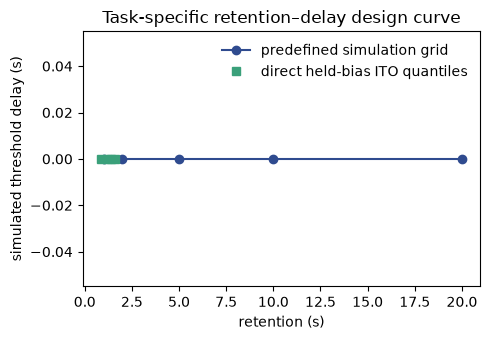

In [5]:
from mrl_trace.maze import run_retention_delay_curve_adaptive

if RUN_PROFILE == "publication":
    horizon_seeds, horizon_episodes = 20, 800
    delay_ratios, training_taus = (3, 5, 7, 9, 12, 16, 20), (1., 2., 5., 10., 20., 40.)
elif RUN_PROFILE == "reduced":
    horizon_seeds, horizon_episodes = 6, 300
    delay_ratios, training_taus = (4, 8, 12, 16, 20), (1., 2., 5., 10., 20.)
else:
    horizon_seeds, horizon_episodes = 2, 80
    delay_ratios, training_taus = (4, 8, 12, 16, 20), (1., 2., 5., 10.)

started = time.perf_counter()
horizon_grid = run_retention_delay_curve_adaptive(
    seeds=horizon_seeds, episodes=horizon_episodes, taus=training_taus,
    delay_ratios=delay_ratios, workers=WORKERS, device_k=selected_k,
    tau_r_override=tau_r_15, beta_leak=held_bias_beta,
    retention_definition="deliberately_swept",
)
ito_point_taus = sorted(set(round(tau, 4) for tau in retention_quantiles))
horizon_ito_points = run_retention_delay_curve_adaptive(
    seeds=horizon_seeds, episodes=horizon_episodes, taus=ito_point_taus,
    delay_ratios=delay_ratios, workers=WORKERS, device_k=selected_k,
    tau_r_override=tau_r_15, beta_leak=held_bias_beta,
    retention_definition="measured_held_bias_quantiles",
)
x = np.asarray(horizon_grid["taus"], float)
y = np.asarray([horizon_grid["dmax"][tau] for tau in horizon_grid["taus"]], float)
hx = np.asarray(horizon_ito_points["taus"], float)
observed = np.asarray([horizon_ito_points["dmax"][tau] for tau in horizon_ito_points["taus"]], float)
resolved = (y > 0) & ~np.asarray(horizon_grid["censored"], bool)
local_slopes = np.diff(y[resolved]) / np.diff(x[resolved]) if resolved.sum() > 1 else np.array([])
curvature = np.diff(local_slopes) if len(local_slopes) > 1 else np.array([])
horizon_diagnostics = {
    "grid_points": len(x), "direct_held_bias_quantile_points": len(hx),
    "eligibility_kinetics": eligibility_kinetics_metadata,
    "training_grid_retention_definition": horizon_grid["retention_definition"],
    "ito_points_retention_definition": horizon_ito_points["retention_definition"],
    "resolved_grid_points": int(resolved.sum()),
    "local_slopes": local_slopes, "curvature": curvature,
    "interpretation": "simulation sensitivity; direct ITO quantiles are not independent physical validation",
    "method_provenance": {"status": "proposed",
        "established_basis": ["eligibility-trace decay", "threshold analysis"],
        "repository_adaptation": "retention is swept inside the same delayed task",
        "claim_limit": "internally generated design sensitivity, not an independent physical law"},
}
horizon_seconds = time.perf_counter() - started
display({"diagnostics": horizon_diagnostics, "elapsed_s": horizon_seconds})

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(x, y, "o-", color="#2f4b8f", label="predefined simulation grid")
ax.plot(hx, observed, "s", color="#3aa07a", label="direct held-bias ITO quantiles")
ax.set(xlabel="retention (s)", ylabel="simulated threshold delay (s)",
       title="Task-specific retention–delay design curve")
ax.legend(frameon=False); fig.tight_layout()
finish(fig, "fig_nmi_retention_delay.png",
       ("horizon_grid.seed_grid", "horizon_ito_points.seed_grid"))


## 4. Within-trial reversal sensitivity

The shared reversal runner compares device and post-peak decay-matched exponential filters across all four held-bias retention quantiles after calibrating reward-time effective-update RMS on 256 common untrained streams, each observed for eight trials. Eligibility is reset at the start of every trial, so any retention dependence is a within-trial filtering sensitivity, not persistence across the reversal boundary or evidence for a general retention--flexibility cost. Recovery is summarized with Kaplan--Meier medians and restricted means at the common horizon; censored seeds remain non-events and null differences are retained.


{'summary': [{'tau_s': 0.8448946663770562,
   'condition': 'device',
   'pre_rate': 0.9433333333333334,
   'post_rate': 0.9349999999999999,
   'recovery_survival': {'kaplan_meier_median_trials': 100.0,
    'median_status': 'observed',
    'restricted_mean_trials': 100.0,
    'restriction_horizon_trials': 600.0,
    'recovered_fraction': 1.0,
    'censored_fraction': 0.0,
    'n_seeds': 6},
   'trace_reset_each_trial': True,
   'eligibility_normalizer': 4.2229849982804435e-05,
   'calibration_raw_effective_update_rms': 4.2229849982804435e-05,
   'evaluation_normalized_effective_update_rms': 1.0768353292577502},
  {'tau_s': 0.8448946663770562,
   'condition': 'abstract',
   'pre_rate': 0.9108333333333333,
   'post_rate': 0.9216666666666665,
   'recovery_survival': {'kaplan_meier_median_trials': 100.0,
    'median_status': 'observed',
    'restricted_mean_trials': 100.0,
    'restriction_horizon_trials': 600.0,
    'recovered_fraction': 1.0,
    'censored_fraction': 0.0,
    'n_seeds': 6}

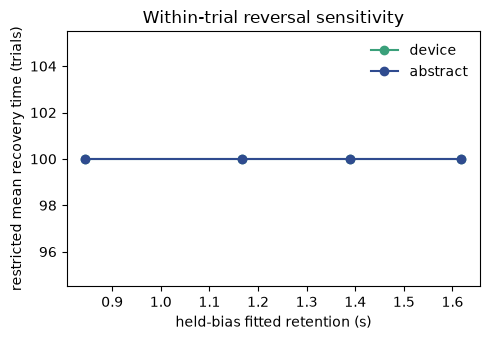

In [6]:
from mrl_trace.bandit import (kaplan_meier_recovery_summary, run_reversal_grid,
                              reversal_phase_final, reversal_recriterion)

if RUN_PROFILE == "publication":
    reversal_seeds, reversal_trials, dt, cue_dur, reward_delay = 20, 3000, 0.005, 1.0, 2.0
elif RUN_PROFILE == "reduced":
    reversal_seeds, reversal_trials, dt, cue_dur, reward_delay = 6, 1200, 0.01, 0.6, 1.0
else:
    reversal_seeds, reversal_trials, dt, cue_dur, reward_delay = 3, 400, 0.02, 0.4, 0.6

started = time.perf_counter()
reversal_grid = run_reversal_grid(
    retention_quantiles, conditions=("device", "abstract"), workers=WORKERS,
    calibration_trajectories=256, calibration_trials=8,
    retention_definition="measured_held_bias_quantiles",
    B=reversal_seeds, trials=reversal_trials, n_phases=2,
    dt=dt, cue_dur=cue_dur, D=reward_delay, device_k=selected_k,
    tau_r_override=tau_r_09, beta_leak=held_bias_beta,
)
reversal_rows = []
reversal_raw = reversal_grid["cells"]
for tau in retention_quantiles:
    for condition in ("device", "abstract"):
        rewards, flips, cell_diagnostics = reversal_raw[(float(tau), condition)]
        calibration = reversal_grid["calibration"]["records"][(float(tau), condition)]
        window = min(200, reversal_trials // 5)
        pre, post = reversal_phase_final(rewards, flips, reversal_trials, window=window)
        criterion_window = min(100, max(20, reversal_trials // 10))
        for seed in range(reversal_seeds):
            recovery = reversal_recriterion(rewards[seed], flips[0], 0.75, window=criterion_window)
            reversal_rows.append({
                "tau_s": float(tau), "condition": condition, "seed": seed,
                "pre_rate": float(pre[seed]), "post_rate": float(post[seed]),
                "recovery_or_censoring_trials": (
                    int(recovery) if recovery is not None else reversal_trials - int(flips[0])
                ),
                "followup_horizon_trials": reversal_trials - int(flips[0]),
                "recovery_censored": recovery is None,
                "trace_reset_each_trial": bool(cell_diagnostics["trace_reset_each_trial"]),
                "eligibility_normalizer": float(calibration["eligibility_normalizer"]),
                "calibration_raw_effective_update_rms": float(calibration["raw_effective_update_rms"]),
                "calibration_normalized_effective_update_rms": float(calibration["normalized_effective_update_rms"]),
                "evaluation_raw_effective_update_rms": float(cell_diagnostics["raw_effective_update_rms"]),
                "evaluation_normalized_effective_update_rms": float(cell_diagnostics["normalized_effective_update_rms"]),
            })
reversal_seconds = time.perf_counter() - started
reversal_summary = []
for tau in retention_quantiles:
    for condition in ("device", "abstract"):
        rows = [row for row in reversal_rows if row["tau_s"] == float(tau) and row["condition"] == condition]
        survival = kaplan_meier_recovery_summary(
            [row["recovery_or_censoring_trials"] for row in rows],
            [row["recovery_censored"] for row in rows],
            rows[0]["followup_horizon_trials"],
        )
        reversal_summary.append({
            "tau_s": float(tau), "condition": condition,
            "pre_rate": float(np.mean([row["pre_rate"] for row in rows])),
            "post_rate": float(np.mean([row["post_rate"] for row in rows])),
            "recovery_survival": survival,
            "trace_reset_each_trial": bool(all(row["trace_reset_each_trial"] for row in rows)),
            "eligibility_normalizer": float(rows[0]["eligibility_normalizer"]),
            "calibration_raw_effective_update_rms": float(rows[0]["calibration_raw_effective_update_rms"]),
            "evaluation_normalized_effective_update_rms": float(rows[0]["evaluation_normalized_effective_update_rms"]),
        })
reversal_diagnostics = {
    "trace_reset_each_trial": bool(all(row["trace_reset_each_trial"] for row in reversal_rows)),
    "calibration": reversal_grid["calibration"],
    "interpretation": reversal_grid["interpretation"],
    "beta_leak": held_bias_beta,
    "retention_definition": reversal_grid["retention_definition"],
}
display({"summary": reversal_summary, "diagnostics": reversal_diagnostics,
         "elapsed_s": reversal_seconds})

fig, ax = plt.subplots(figsize=(5, 3.5))
for condition, colour in (("device", "#3aa07a"), ("abstract", "#2f4b8f")):
    rows = [row for row in reversal_summary if row["condition"] == condition]
    ax.plot([row["tau_s"] for row in rows],
            [row["recovery_survival"]["restricted_mean_trials"] for row in rows],
            "o-", color=colour, label=condition)
ax.set(xlabel="held-bias fitted retention (s)",
       ylabel="restricted mean recovery time (trials)",
       title="Within-trial reversal sensitivity")
ax.legend(frameon=False); fig.tight_layout()
finish(fig, "fig_nmi_reversal.png",
       ("reversal_grid.cells", "reversal_rows"))


## Resource-matched co-design boundary

The empirical model selection above is also the provenance layer for the separate resource-matched temporal-attribution analysis in `mrl_trace.codesign`. That analysis compares the shared physical and linear specifications with a decay-matched exponential and an equal-state learned basis on disjoint synthetic timing blocks. It records this notebook's predictive-linkage manifest digest when the manifest is available, but it does not consume held-out Au scores, ITO parameters, or notebook execution state when fitting the synthetic comparator. This preserves a clean boundary between empirical representation support and downstream performance. Its operation counts are structural lower bounds, not measured energy or area.


## Result archive and interpretation

No result is written by default. When saving is enabled, the complete Python result objects and a compact JSON report are placed in the chosen output directory, which should be archived with the environment, commit and execution log. Publication-profile output belongs in the DOI deposit, not the Git repository.

Smoke and reduced profiles validate deterministic execution at their declared scale; publication claims remain tied to the tracked publication artifacts. The notebook reports scientific diagnostics and does not substitute venue prediction for evidence.


In [7]:
def jsonable(value):
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, (np.floating, float)):
        number = float(value); return number if math.isfinite(number) else None
    if isinstance(value, np.integer): return int(value)
    if isinstance(value, dict): return {str(key): jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)): return [jsonable(item) for item in value]
    return value

predictive_linkage_manifest = build_predictive_linkage_manifest(
    candidate_scores=state_space_comparison["mean_nrmse"],
    source_digests={f'{row["dataset"]}/{row["filename"]}': row["sha256"] for row in raw_rows},
    parameter_estimates={"gold": gold_result["parameters"], "ito_summary": ito_result["summary"]},
    retention_definition="direct_held_bias_tau",
    software_versions=ENVIRONMENT_RECORD["packages"], tolerance=0.05,
)
assert predictive_linkage_manifest["model_specifications"][PRIMARY_MODEL_ID]["spec_digest_sha256"] == device_model_spec(PRIMARY_MODEL_ID)["spec_digest_sha256"]
assert {row["filename"] for row in FIGURE_REPORT} == set(OWNED)
run_report = {
    "profile": RUN_PROFILE, "bootstrap": BOOTSTRAP, "workers": WORKERS,
    "selected_k": selected_k, "supported_k": supported_k,
    "candidate_representation": selected_law, "retention_quantiles_s": retention_quantiles,
    "eligibility_kinetics": eligibility_kinetics_metadata,
    "analysis_schema_version": 2, "retention_definition": "direct_held_bias_tau",
    "measurement_regime": {
        "primary": "held_bias_workbook_run",
        "separate_preliminary": ito_result["summary"]["near_zero_read"],
    },
    "physical_evidence": evidence, "state_space_comparison": state_space_comparison,
    "identifiability_support": identifiability_support,
    "kernel_theory_rows": kernel_theory_rows,
    "timing_battery": timing_battery,
    "falsification_predictions": falsification_predictions,
    "predictive_linkage_manifest_digest": predictive_linkage_manifest["manifest_digest_sha256"],
    "interval_diagnostics": interval_result["diagnostics"],
    "interval_delay_grid_s": interval_result["delay_grid"],
    "interval_grid_source": interval_result["grid_source"],
    "interval_peak_censoring": interval_result["peak_censoring"],
    "interval_null_controls": {
        "control_peak_correlations": interval_result["diagnostics"]["control_peak_correlations"],
        "shuffled_prediction_one_sided_p": interval_result["diagnostics"]["shuffled_prediction_one_sided_p"],
    },
    "horizon_diagnostics": horizon_diagnostics, "reversal_summary": reversal_summary,
    "figure_registry": FIGURE_REPORT,
    "reversal_diagnostics": reversal_diagnostics,
    "evidential_use": "publication-scale" if RUN_PROFILE == "publication" else "feasibility-only",
    "editorial_decision": ("physical_within_5pct_of_best"
                           if state_space_selection["physical_within_tolerance"]
                           else "physical_not_empirically_preferred"),
    "provenance": PROVENANCE_RECORD,
    "method_provenance": {
        "physical_identification": gold_result["method_provenance"],
        "ito_retention": ito_result["summary"]["method_provenance"],
        "timing_sweep": interval_result["method_provenance"],
        "retention_delay_curve": horizon_diagnostics["method_provenance"],
        "reversal": reversal_grid["method_provenance"],
    },
}
notebook_summary = {
    "profile": RUN_PROFILE,
    "raw_files": len(raw_rows),
    "au_traces": gold_result["trace_count"],
    "ito_primary_workbooks": ito_result["summary"]["primary_workbooks"],
    "ito_near_zero_supplements": ito_result["summary"]["supplemental_near_zero_workbooks"],
    "held_out_best": state_space_selection["best_candidate"],
    "within_five_percent": state_space_selection["within_tolerance"],
    "physical_empirically_preferred": state_space_selection["physical_within_tolerance"],
    "prediction_manifest_sha256": predictive_linkage_manifest["manifest_digest_sha256"],
}
print(notebook_summary)

if SAVE_RESULTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    interval_seed_rows = [
        {"tau_s": row["tau_s"], "delay_s": row["delay_s"],
         "condition": row["condition"], "seed": seed, "selectivity": float(value)}
        for row in interval_result["rows"]
        for seed, value in enumerate(row["seed_values"])
    ]
    horizon_seed_rows = []
    for regime, result in (("deliberately_swept", horizon_grid),
                           ("measured_held_bias_quantiles", horizon_ito_points)):
        for tau, delay_rows in result["seed_grid"].items():
            for delay, values in delay_rows.items():
                for seed, value in enumerate(values):
                    horizon_seed_rows.append({"retention_regime": regime,
                        "tau_s": tau, "delay_s": delay, "seed": seed,
                        "final_reward_rate": float(value)})
    figure_sources = [
        {"filename": "fig_nmi_physical_model.png",
         "sources": ["raw_manifest.csv", "gold_cv_rows.csv", "gold_fit_rows.csv", "ito_fit_rows.csv"]},
        {"filename": "fig_nmi_predictive_timing.png",
         "sources": ["predictive_interval_seeds.csv", "run_report.json"]},
        {"filename": "fig_nmi_retention_delay.png",
         "sources": ["retention_delay_seeds.csv", "run_report.json"]},
        {"filename": "fig_nmi_reversal.png",
         "sources": ["reversal_seeds.csv", "run_report.json"]},
    ]
    write_csv(OUTPUT_DIR / "raw_manifest.csv", raw_rows)
    write_json(OUTPUT_DIR / "raw_manifest.json", raw_rows)
    write_csv(OUTPUT_DIR / "gold_cv_rows.csv", gold_result["cv_rows"])
    write_csv(OUTPUT_DIR / "gold_fit_rows.csv", gold_result["fit_rows"])
    write_csv(OUTPUT_DIR / "ito_fit_rows.csv", ito_result["rows"])
    write_csv(OUTPUT_DIR / "predictive_interval_seeds.csv", interval_seed_rows)
    write_csv(OUTPUT_DIR / "retention_delay_seeds.csv", horizon_seed_rows)
    write_csv(OUTPUT_DIR / "reversal_seeds.csv", reversal_rows)
    write_json(OUTPUT_DIR / "figure_sources.json", figure_sources)
    write_json(OUTPUT_DIR / "gold_parameters.json", gold_result["parameters"])
    write_json(OUTPUT_DIR / "predictive_linkage_manifest.json", predictive_linkage_manifest)
    write_json(OUTPUT_DIR / "identifiability_support.json", identifiability_support)
    write_csv(OUTPUT_DIR / "kernel_theory_rows.csv", kernel_theory_rows)
    write_json(OUTPUT_DIR / "timing_battery.json", timing_battery)
    write_json(OUTPUT_DIR / "falsification_predictions.json", falsification_predictions)
    write_json(OUTPUT_DIR / "run_report.json", run_report)
    payload = {
        "run_report": run_report, "raw_manifest": raw_rows, "gold": gold_result,
        "ito": ito_result, "interval": interval_result, "structure": structure_results,
        "retention_grid": horizon_grid, "retention_ito_points": horizon_ito_points,
        "reversal_grid": reversal_grid, "reversal_rows": reversal_rows,
    }
    np.save(OUTPUT_DIR / f"nmi_predictive_linkage_{RUN_PROFILE}.npy", payload, allow_pickle=True)
    (OUTPUT_DIR / f"nmi_predictive_linkage_{RUN_PROFILE}.json").write_text(
        json.dumps(jsonable(run_report), indent=2, allow_nan=False) + "\n", encoding="utf-8")
    print(f"saved result archive to {OUTPUT_DIR}")


{'profile': 'reduced', 'raw_files': 117, 'au_traces': 24, 'ito_primary_workbooks': 91, 'ito_near_zero_supplements': 2, 'held_out_best': 'linear_k3', 'within_five_percent': ['kww', 'linear_k2', 'linear_k3', 'linear_k4', 'linear_k5'], 'physical_empirically_preferred': False, 'prediction_manifest_sha256': '15eccca211a42343c1d4410f73c92b95d955207a3db97eb0d5087fe9ecf42c85'}
